# 01C — Complementary Purchase Analysis

**Rubric target:** Data Acquisition & Analysis

This notebook explores whether customers exhibit complementary purchasing behavior —
buying items that "go together" rather than just repurchasing the same things or
browsing substitutes. The findings here inform candidate generation strategy and
feed into the Potential Improvements section of the final report.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/MLII_Final'

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter
from pathlib import Path

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = ['#2D2D2D', '#A8C8E8', '#C4D9A0', '#D4B8E0', '#F2C4C4', '#FFD9A0', '#E8D5B7']

DATA_DIR = Path(f'{PROJECT}/data/parquet')
FIG_DIR = Path(f'{PROJECT}/outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
transactions = pd.read_parquet(DATA_DIR / 'transactions.parquet')
articles     = pd.read_parquet(DATA_DIR / 'articles.parquet')

# Merge article metadata onto transactions
txn = transactions.merge(
    articles[['article_id', 'product_type_name', 'product_group_name',
              'department_name', 'index_group_name', 'garment_group_name']],
    on='article_id', how='left'
)

print(f"Transactions with metadata: {len(txn):,}")

Transactions with metadata: 31,788,324


---
## 1. Defining "Baskets"

Each row in the dataset is a single item purchase, not a basket. We define a basket
as all items purchased by the same customer on the same day. This is an approximation —
a customer could make two separate trips in one day — but it's the best proxy we have.

In [4]:
baskets = txn.groupby(['customer_id', 't_dat'])
basket_sizes = baskets.size()

print(f"Total baskets: {len(basket_sizes):,}")
print(f"Baskets with >1 item (multi-item): {(basket_sizes > 1).sum():,} ({(basket_sizes > 1).mean()*100:.1f}%)")
print(f"Baskets with >1 item needed for co-purchase analysis.")
print(f"\nMulti-item basket size distribution:")
multi = basket_sizes[basket_sizes > 1]
print(f"  Mean:   {multi.mean():.1f}")
print(f"  Median: {multi.median():.0f}")
print(f"  Max:    {multi.max()}")

Total baskets: 9,080,179
Baskets with >1 item (multi-item): 6,393,136 (70.4%)
Baskets with >1 item needed for co-purchase analysis.

Multi-item basket size distribution:
  Mean:   4.6
  Median: 3
  Max:    570


---
## 2. Co-Purchase Category Analysis

For every multi-item basket, which department pairs appear together?
We compute both raw co-occurrence counts and **lift** (observed / expected)
to separate "both popular" from "genuinely bought together."

In [5]:
# Build department-level baskets (only multi-item)
dept_baskets = (
    txn.groupby(['customer_id', 't_dat'])['department_name']
    .apply(list)
    .reset_index()
)
dept_baskets = dept_baskets[dept_baskets['department_name'].apply(len) > 1]

print(f"Multi-item baskets for co-purchase analysis: {len(dept_baskets):,}")

Multi-item baskets for co-purchase analysis: 6,393,136


In [6]:
# Count co-occurrences of department pairs
pair_counts = Counter()
dept_in_basket_counts = Counter()  # for marginal probabilities
n_baskets_total = len(dept_baskets)

for _, row in dept_baskets.iterrows():
    depts = set(row['department_name'])  # unique departments in this basket
    for d in depts:
        dept_in_basket_counts[d] += 1
    for a, b in combinations(sorted(depts), 2):
        pair_counts[(a, b)] += 1

print(f"Unique department pairs observed: {len(pair_counts):,}")
print(f"\nTop 15 co-purchased department pairs (raw count):")
for (a, b), count in sorted(pair_counts.items(), key=lambda x: -x[1])[:15]:
    print(f"  {a:30s} + {b:30s}  {count:,}")

Unique department pairs observed: 26,873

Top 15 co-purchased department pairs (raw count):
  Blouse                         + Trouser                         223,755
  Blouse                         + Jersey                          182,162
  Blouse                         + Jersey fancy                    176,426
  Jersey                         + Jersey Basic                    166,740
  Jersey                         + Jersey fancy                    165,130
  Knitwear                       + Trouser                         164,439
  Jersey fancy                   + Trouser                         156,864
  Jersey                         + Trouser                         155,179
  Basic 1                        + Jersey Basic                    147,999
  Jersey Basic                   + Jersey fancy                    146,684
  Blouse                         + Knitwear                        143,331
  Dress                          + Jersey                          141,823
  Ladies

In [7]:
# Compute lift for each pair
# Lift = P(A and B) / (P(A) * P(B))
# Lift > 1 means they co-occur more than expected by chance

lift_data = []
for (a, b), count in pair_counts.items():
    p_ab = count / n_baskets_total
    p_a = dept_in_basket_counts[a] / n_baskets_total
    p_b = dept_in_basket_counts[b] / n_baskets_total
    lift = p_ab / (p_a * p_b) if (p_a * p_b) > 0 else 0
    lift_data.append({'dept_a': a, 'dept_b': b, 'count': count, 'lift': lift})

lift_df = pd.DataFrame(lift_data)

# Filter to pairs with meaningful volume (at least 100 co-occurrences)
lift_significant = lift_df[lift_df['count'] >= 100].sort_values('lift', ascending=False)

print("Top 20 department pairs by LIFT (min 100 co-occurrences):")
print(f"{'Dept A':30s} {'Dept B':30s} {'Count':>8s} {'Lift':>6s}")
print("-" * 78)
for _, row in lift_significant.head(20).iterrows():
    marker = " ← genuine complement" if row['lift'] > 2 else ""
    print(f"{row['dept_a']:30s} {row['dept_b']:30s} {row['count']:>8,} {row['lift']:>6.2f}{marker}")

Top 20 department pairs by LIFT (min 100 co-occurrences):
Dept A                         Dept B                            Count   Lift
------------------------------------------------------------------------------
Bottoms Boys                   Tops Boys                           156 4932.54 ← genuine complement
Sneakers big girl inactive from s2 Young Girl Shoes                    103 456.51 ← genuine complement
Kids Girl Shoes                Sneakers small girl inactive from s2      212 356.28 ← genuine complement
Baby Boy Outdoor               Baby Girl Outdoor                   252 273.46 ← genuine complement
Blazer S&T                     Trouser S&T                       4,584 233.58 ← genuine complement
Men Sport Bottoms              Men Sport Woven                   2,070 232.19 ← genuine complement
Kids Girl Big Acc              Young Girl Big Acc                  393 215.42 ← genuine complement
Baby Boy Knitwear              Baby Boy Woven                    2,144 213.87 ← g

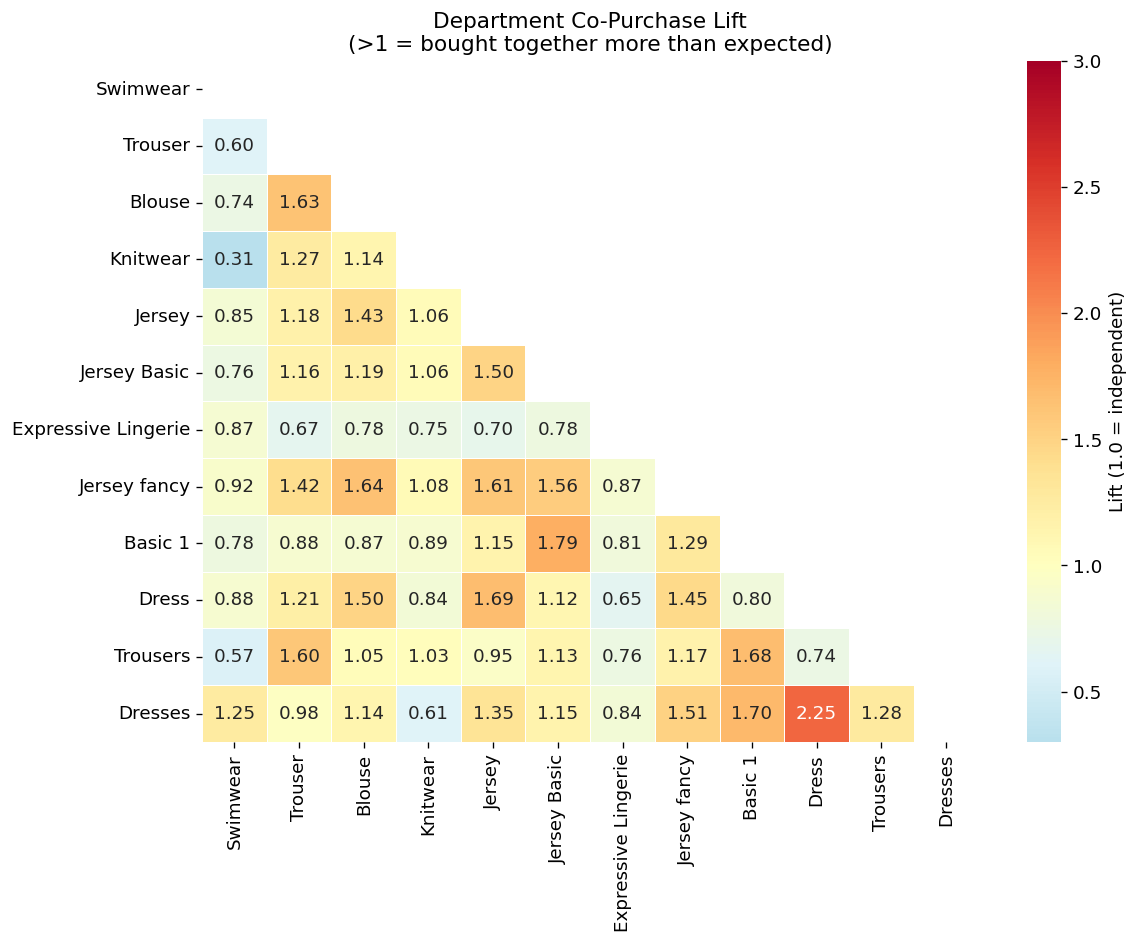

In [8]:
# Heatmap of lift for top departments
top_depts = (
    txn['department_name'].value_counts().head(12).index.tolist()
)

# Build lift matrix
lift_matrix = pd.DataFrame(1.0, index=top_depts, columns=top_depts)
for _, row in lift_df.iterrows():
    if row['dept_a'] in top_depts and row['dept_b'] in top_depts:
        lift_matrix.loc[row['dept_a'], row['dept_b']] = row['lift']
        lift_matrix.loc[row['dept_b'], row['dept_a']] = row['lift']

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(lift_matrix, dtype=bool), k=0)
sns.heatmap(
    lift_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
    center=1.0, vmin=0.3, vmax=3.0, linewidths=0.5,
    cbar_kws={'label': 'Lift (1.0 = independent)'},
    ax=ax
)
ax.set_title('Department Co-Purchase Lift\n(>1 = bought together more than expected)')
plt.tight_layout()
fig.savefig(FIG_DIR / 'department_copurchase_lift.png', bbox_inches='tight')
plt.show()

---
## 3. Cross-Department vs Single-Department Baskets

Do customers tend to buy within one department (substitute/replenishment shopping)
or across departments (outfit-building / complement shopping)?

In [9]:
# For each multi-item basket, count unique departments
dept_diversity = (
    txn.groupby(['customer_id', 't_dat'])
    .agg(
        n_items=('article_id', 'count'),
        n_departments=('department_name', 'nunique'),
        n_product_types=('product_type_name', 'nunique'),
    )
)

multi_item = dept_diversity[dept_diversity['n_items'] > 1].copy()
multi_item['all_same_dept'] = multi_item['n_departments'] == 1

same_dept_pct = multi_item['all_same_dept'].mean() * 100
cross_dept_pct = 100 - same_dept_pct

print(f"Multi-item baskets: {len(multi_item):,}")
print(f"  All items from same department: {same_dept_pct:.1f}% (substitute/replenishment)")
print(f"  Items span multiple departments: {cross_dept_pct:.1f}% (potential complement shopping)")

print(f"\nDepartment diversity in multi-item baskets:")
print(f"  Mean unique departments: {multi_item['n_departments'].mean():.2f}")
print(f"  Mean unique product types: {multi_item['n_product_types'].mean():.2f}")

Multi-item baskets: 6,393,136
  All items from same department: 20.2% (substitute/replenishment)
  Items span multiple departments: 79.8% (potential complement shopping)

Department diversity in multi-item baskets:
  Mean unique departments: 2.82
  Mean unique product types: 2.70


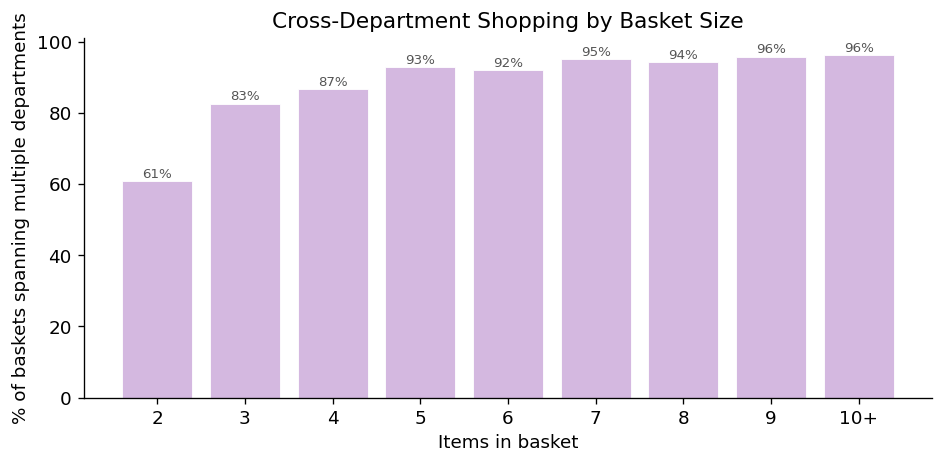

In [10]:
# Does cross-department shopping increase with basket size?
by_basket_size = (
    multi_item
    .groupby(multi_item['n_items'].clip(upper=10))
    .agg(
        n_baskets=('n_departments', 'count'),
        avg_departments=('n_departments', 'mean'),
        pct_cross_dept=('all_same_dept', lambda x: (1 - x.mean()) * 100),
    )
    .round(1)
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_basket_size.index, by_basket_size['pct_cross_dept'],
       color=PALETTE[3], edgecolor='white', linewidth=0.5)
ax.set_title('Cross-Department Shopping by Basket Size')
ax.set_xlabel('Items in basket')
ax.set_ylabel('% of baskets spanning multiple departments')
ax.set_xticks(by_basket_size.index)
ax.set_xticklabels([str(i) if i < 10 else '10+' for i in by_basket_size.index])
for i, (idx, row) in enumerate(by_basket_size.iterrows()):
    ax.text(idx, row['pct_cross_dept'] + 1, f"{row['pct_cross_dept']:.0f}%",
            ha='center', fontsize=8, color='#555')
plt.tight_layout()
fig.savefig(FIG_DIR / 'cross_dept_by_basket_size.png', bbox_inches='tight')
plt.show()

---
## 4. Sequential Complement Patterns

Beyond same-day baskets: if a customer buys item A, what categories do they
buy within the **next 7 days**? This captures "I bought this, now I need
something to go with it" behavior.

In [11]:
# Sort transactions by customer and date
txn_sorted = txn.sort_values(['customer_id', 't_dat']).copy()

# For efficiency, sample a subset of active customers
np.random.seed(42)
active_customers = txn_sorted.groupby('customer_id').size()
active_customers = active_customers[active_customers >= 5].index
sampled_customers = np.random.choice(active_customers, size=min(50000, len(active_customers)), replace=False)

txn_sample = txn_sorted[txn_sorted['customer_id'].isin(sampled_customers)].copy()
print(f"Sampled {len(sampled_customers):,} customers with ≥5 purchases")
print(f"Transactions in sample: {len(txn_sample):,}")

Sampled 50,000 customers with ≥5 purchases
Transactions in sample: 1,678,258


In [12]:
# For each purchase, find what departments were purchased 1-7 days later
FOLLOWUP_WINDOW = 7  # days

sequential_pairs = Counter()
dept_starts = Counter()

for cid, group in txn_sample.groupby('customer_id'):
    dates = group['t_dat'].values
    depts = group['department_name'].values

    for i in range(len(group)):
        seed_dept = depts[i]
        seed_date = dates[i]
        dept_starts[seed_dept] += 1

        for j in range(i + 1, len(group)):
            days_diff = (dates[j] - seed_date) / np.timedelta64(1, 'D')
            if days_diff < 1:  # same day — skip, already covered above
                continue
            if days_diff > FOLLOWUP_WINDOW:
                break
            follow_dept = depts[j]
            if follow_dept != seed_dept:  # only cross-department
                sequential_pairs[(seed_dept, follow_dept)] += 1

print(f"Unique sequential department pairs (A → B within {FOLLOWUP_WINDOW} days): {len(sequential_pairs):,}")

Unique sequential department pairs (A → B within 7 days): 27,285


In [13]:
# Compute conditional probability: P(buy dept B within 7 days | just bought dept A)
seq_df = pd.DataFrame([
    {'seed_dept': a, 'follow_dept': b, 'count': c,
     'p_follow_given_seed': c / dept_starts[a] if dept_starts[a] > 0 else 0}
    for (a, b), c in sequential_pairs.items()
])

# Top sequential patterns
seq_significant = seq_df[seq_df['count'] >= 50].sort_values('p_follow_given_seed', ascending=False)

print(f"Top 20 sequential complement patterns (min 50 occurrences):")
print(f"{'After buying...':30s} {'→ then buy...':30s} {'Count':>7s} {'P(follow|seed)':>14s}")
print("-" * 85)
for _, row in seq_significant.head(20).iterrows():
    print(f"{row['seed_dept']:30s} → {row['follow_dept']:28s} {row['count']:>7,} {row['p_follow_given_seed']:>13.3f}")

Top 20 sequential complement patterns (min 50 occurrences):
After buying...                → then buy...                    Count P(follow|seed)
-------------------------------------------------------------------------------------
Divided Swimwear               → Swimwear                       1,000         0.770
AK Tops Knitwear               → Tops Knitwear                     53         0.405
AK Tops Knitwear               → Basic 1                           51         0.389
Boys Local Relevance           → Tops Fancy Jersey                148         0.351
Kids Boy Shorts                → Swimwear                          92         0.293
Blazer                         → Trouser                           55         0.258
Shorts DS                      → Swimwear                          80         0.258
Baby Shoes                     → Swimwear                         148         0.253
Kids Boy Shorts                → Hair Accessories                  79         0.252
Boys Local Re

---
## 5. Repeat vs Complement vs Explore Breakdown

For each customer's purchase history, classify each item (after the first) as:
- **Repurchase**: same article_id they've bought before
- **Same-category**: same product type but different article (substitute)
- **Cross-category**: different department (potential complement / exploration)

In [21]:
classifications = {'repurchase': 0, 'same_category': 0, 'cross_category': 0}
by_position = []  # track how this changes over purchase sequence

for cid, group in txn_sample.groupby('customer_id'):
    seen_articles = set()
    seen_product_types = set()

    for idx, (_, row) in enumerate(group.iterrows()):
        if idx == 0:
            seen_articles.add(row['article_id'])
            seen_product_types.add(row['product_type_name'])
            continue

        if row['article_id'] in seen_articles:
            label = 'repurchase'
        elif row['product_type_name'] in seen_product_types:
            label = 'same_category'
        else:
            label = 'cross_category'

        classifications[label] += 1
        # Bucket position for trend analysis (cap at 50)
        by_position.append({'position': min(idx, 50), 'label': label})

        seen_articles.add(row['article_id'])
        seen_product_types.add(row['product_type_name'])

total_classified = sum(classifications.values())
print("Purchase classification (after first purchase):")
for label, count in classifications.items():
    print(f"  {label:20s} {count:>10,}  ({count/total_classified*100:.1f}%)")

Purchase classification (after first purchase):
  repurchase              243,842  (15.0%)
  same_category           913,406  (56.1%)
  cross_category          471,010  (28.9%)


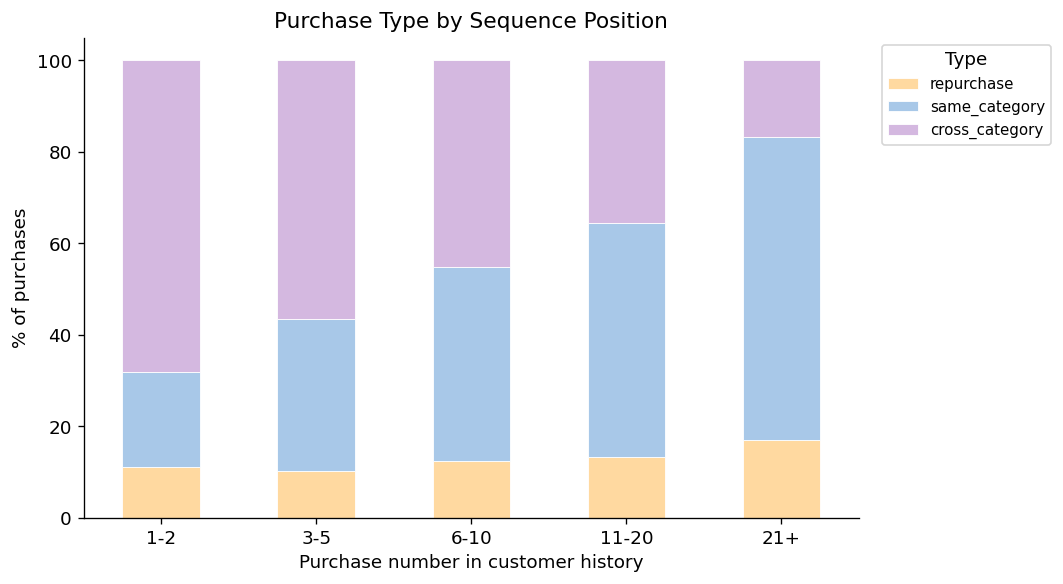


Interpretation:
- If repurchase % grows with sequence position → customers settle into habits
- If cross-category % stays high → complement/exploration is a persistent signal
- If same-category dominates → substitute shopping is the primary mode


In [22]:
# How does the mix change over the purchase sequence?
pos_df = pd.DataFrame(by_position)

# Bucket into purchase sequence ranges for cleaner visualization
bins = [0, 2, 5, 10, 20, 51]
labels = ['1-2', '3-5', '6-10', '11-20', '21+']
pos_df['position_bucket'] = pd.cut(pos_df['position'], bins=bins, labels=labels, right=False)

mix = (
    pos_df
    .groupby(['position_bucket', 'label'], observed=False)
    .size()
    .unstack(fill_value=0)
)
mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 5))
mix_pct[['repurchase', 'same_category', 'cross_category']].plot(
    kind='bar', stacked=True, ax=ax,
    color=[PALETTE[5], PALETTE[1], PALETTE[3]],
    edgecolor='white', linewidth=0.5
)
ax.set_title('Purchase Type by Sequence Position')
ax.set_xlabel('Purchase number in customer history')
ax.set_ylabel('% of purchases')
ax.legend(title='Type', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
fig.savefig(FIG_DIR / 'purchase_type_by_sequence.png', bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("- If repurchase % grows with sequence position → customers settle into habits")
print("- If cross-category % stays high → complement/exploration is a persistent signal")
print("- If same-category dominates → substitute shopping is the primary mode")

---
## 6. Category-Pair Asymmetry

Complements are often directional: buying a dress → buying shoes more often
than buying shoes → buying a dress. We measure this asymmetry using
conditional probabilities.

**P(B | bought A)  vs  P(A | bought B)**

Large asymmetry = strong directional complement relationship.

In [23]:
# Use the co-purchase pairs from section 2, but now compute directional probabilities
# P(B in basket | A in basket) = count(A,B) / count(A)

asymmetry_data = []

for (a, b), count in pair_counts.items():
    p_b_given_a = count / dept_in_basket_counts[a] if dept_in_basket_counts[a] > 0 else 0
    p_a_given_b = count / dept_in_basket_counts[b] if dept_in_basket_counts[b] > 0 else 0

    # Asymmetry ratio: how much more likely is one direction vs the other?
    if min(p_b_given_a, p_a_given_b) > 0:
        asymmetry = max(p_b_given_a, p_a_given_b) / min(p_b_given_a, p_a_given_b)
    else:
        asymmetry = 0

    # Which direction is stronger?
    if p_b_given_a >= p_a_given_b:
        direction = f"{a} → {b}"
    else:
        direction = f"{b} → {a}"

    asymmetry_data.append({
        'dept_a': a, 'dept_b': b, 'count': count,
        'p_b_given_a': p_b_given_a, 'p_a_given_b': p_a_given_b,
        'asymmetry_ratio': asymmetry, 'stronger_direction': direction
    })

asym_df = pd.DataFrame(asymmetry_data)
asym_significant = asym_df[asym_df['count'] >= 100].sort_values('asymmetry_ratio', ascending=False)

print("Top 20 most asymmetric department co-purchase pairs (min 100 co-occurrences):")
print(f"{'Stronger direction':50s} {'Count':>7s} {'Asymmetry':>10s} {'P(→)':>8s} {'P(←)':>8s}")
print("-" * 87)
for _, row in asym_significant.head(20).iterrows():
    print(f"{row['stronger_direction']:50s} {row['count']:>7,} {row['asymmetry_ratio']:>9.2f}x {row['p_b_given_a']:>8.4f} {row['p_a_given_b']:>8.4f}")

Top 20 most asymmetric department co-purchase pairs (min 100 co-occurrences):
Stronger direction                                   Count  Asymmetry     P(→)     P(←)
---------------------------------------------------------------------------------------
Jersey inactive from S.6 → Knitwear                    185   2688.80x   0.5710   0.0002
Local relevance → Trouser                              120   2109.32x   0.2661   0.0001
Test Ladies → Trouser                                  140   1973.66x   0.2905   0.0001
Local relevance → Knitwear                             118   1931.64x   0.0001   0.2616
Test Ladies → Blouse                                   250   1913.71x   0.0003   0.5187
Test Ladies → Jersey                                   130   1833.73x   0.0001   0.2697
Jackets → Blouse                                       107   1560.76x   0.0001   0.1810
Test Ladies → Jersey fancy                             134   1543.51x   0.0002   0.2780
Jackets → Jersey                          

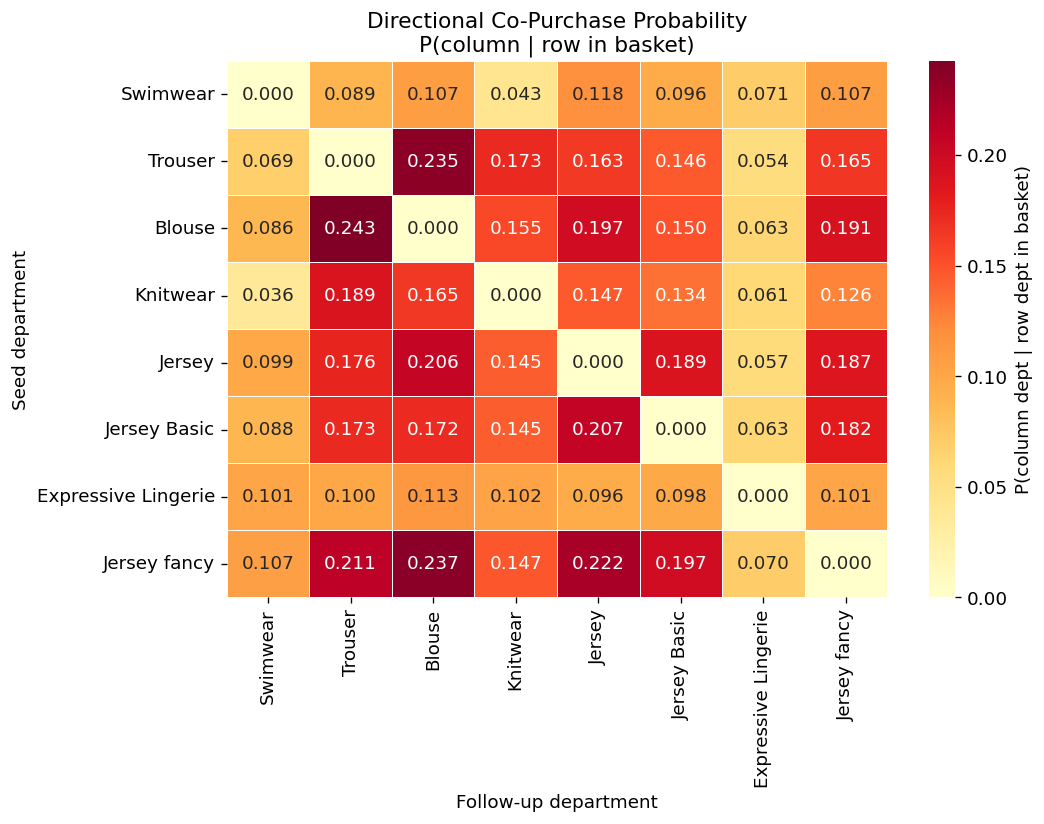


Note: this matrix is NOT symmetric — that's the point.
Read row-wise: 'given a basket contains [row], what's the probability it also contains [col]?'
Asymmetry reveals directional complement relationships.


In [24]:
# Visualize as a directed heatmap for top departments
# Value at [A, B] = P(buy B | basket contains A)

top_depts_8 = txn['department_name'].value_counts().head(8).index.tolist()

cond_matrix = pd.DataFrame(0.0, index=top_depts_8, columns=top_depts_8)
for _, row in asym_df.iterrows():
    if row['dept_a'] in top_depts_8 and row['dept_b'] in top_depts_8:
        cond_matrix.loc[row['dept_a'], row['dept_b']] = row['p_b_given_a']
        cond_matrix.loc[row['dept_b'], row['dept_a']] = row['p_a_given_b']

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cond_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'P(column dept | row dept in basket)'}
)
ax.set_title('Directional Co-Purchase Probability\nP(column | row in basket)')
ax.set_xlabel('Follow-up department')
ax.set_ylabel('Seed department')
plt.tight_layout()
fig.savefig(FIG_DIR / 'directional_copurchase_heatmap.png', bbox_inches='tight')
plt.show()

print("\nNote: this matrix is NOT symmetric — that's the point.")
print("Read row-wise: 'given a basket contains [row], what's the probability it also contains [col]?'")
print("Asymmetry reveals directional complement relationships.")

---
## 7. Product-Type Level Co-Purchase (Finer Grain)

Departments are broad. Let's also look at product type pairs for more
specific complement signals (e.g., "Trousers + Vest top").

In [27]:
# Product-type level co-purchase pairs from multi-item baskets
ptype_baskets = (
    txn.groupby(['customer_id', 't_dat'])['product_type_name']
    .apply(list)
)
ptype_baskets = ptype_baskets[ptype_baskets.apply(len) > 1]

ptype_pairs = Counter()
for items in ptype_baskets:
    unique_types = set(items)
    for a, b in combinations(sorted(unique_types), 2):
        ptype_pairs[(a, b)] += 1

# Top product type pairs
print("Top 25 co-purchased product type pairs:")
print(f"{'Product A':30s} {'Product B':30s} {'Count':>7s}")
print("-" * 70)
for (a, b), count in sorted(ptype_pairs.items(), key=lambda x: -x[1])[:25]:
    print(f"{a:30s} {b:30s} {count:>7,}")

Top 25 co-purchased product type pairs:
Product A                      Product B                        Count
----------------------------------------------------------------------
Sweater                        Trousers                       498,353
Bikini top                     Swimwear bottom                463,018
Dress                          Trousers                       385,100
T-shirt                        Trousers                       366,980
Top                            Trousers                       339,971
Blouse                         Trousers                       312,649
Sweater                        Top                            272,217
Bra                            Underwear bottom               262,678
T-shirt                        Top                            260,369
Sweater                        T-shirt                        255,601
Dress                          Top                            251,357
Blouse                         Dress             

---
## Summary & Implications for Modeling

### Key findings:

In [28]:
print("=" * 70)
print("COMPLEMENTARY PURCHASE ANALYSIS — KEY FINDINGS")
print("=" * 70)
print()
print(f"1. BASKET COMPOSITION")
print(f"   Multi-item baskets: {(basket_sizes > 1).sum():,} ({(basket_sizes > 1).mean()*100:.1f}% of all baskets)")
print(f"   Cross-department baskets: {cross_dept_pct:.1f}% of multi-item baskets")
print()
print(f"2. PURCHASE BEHAVIOR MIX")
for label, count in classifications.items():
    print(f"   {label:20s} {count/total_classified*100:.1f}%")
print()
print(f"3. COMPLEMENT SIGNAL STRENGTH")
high_lift_pairs = len(lift_df[lift_df['lift'] > 2.0])
print(f"   Department pairs with lift > 2.0: {high_lift_pairs}")
high_asym_pairs = len(asym_significant[asym_significant['asymmetry_ratio'] > 2.0])
print(f"   Highly asymmetric pairs (>2x): {high_asym_pairs}")
print()
print("4. IMPLICATIONS")
print("   → Co-purchase patterns exist and could improve candidate generation")
print("   → Complement relationships are asymmetric — direction matters")
print("   → Sequential patterns (within 7 days) capture different signal than same-basket")
print("   → A complement classifier could use co-purchase lift + category metadata")
print("     as training signal (see Potential Improvements section)")

COMPLEMENTARY PURCHASE ANALYSIS — KEY FINDINGS

1. BASKET COMPOSITION
   Multi-item baskets: 6,393,136 (70.4% of all baskets)
   Cross-department baskets: 79.8% of multi-item baskets

2. PURCHASE BEHAVIOR MIX
   repurchase           15.0%
   same_category        56.1%
   cross_category       28.9%

3. COMPLEMENT SIGNAL STRENGTH
   Department pairs with lift > 2.0: 6251
   Highly asymmetric pairs (>2x): 7737

4. IMPLICATIONS
   → Co-purchase patterns exist and could improve candidate generation
   → Complement relationships are asymmetric — direction matters
   → Sequential patterns (within 7 days) capture different signal than same-basket
   → A complement classifier could use co-purchase lift + category metadata
     as training signal (see Potential Improvements section)
